<a href="https://colab.research.google.com/github/musharraf18867/TimetableGenerationSystem/blob/master/Eda%20and%20Ml%20Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, precision_score, classification_report

In [81]:
df=pd.read_csv('/Titanic-Dataset.csv')

In [82]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [83]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [85]:
df.shape

(891, 12)

In [86]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [87]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [88]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [91]:
# Fill missing 'Age' values with the mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Fill missing 'Embarked' values with the mode (most frequent value)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fill missing 'Cabin' values with 'Unknown'
df['Cabin'].fillna('Unknown', inplace=True)

# Convert categorical columns ('Sex', 'Embarked', 'Pclass') to numerical using one-hot encoding
# drop_first=True avoids multicollinearity
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

# Drop 'Name' and 'Ticket' columns as they are typically not used directly as numerical features
df.drop(columns=['Name', 'Ticket',], inplace=True, errors='ignore')

In [92]:
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Sex_male     891 non-null    bool   
 7   Embarked_Q   891 non-null    bool   
 8   Embarked_S   891 non-null    bool   
 9   Pclass_2     891 non-null    bool   
 10  Pclass_3     891 non-null    bool   
dtypes: bool(5), float64(2), int64(4)
memory usage: 46.2 KB


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Sex_male     891 non-null    bool   
 7   Embarked_Q   891 non-null    bool   
 8   Embarked_S   891 non-null    bool   
 9   Pclass_2     891 non-null    bool   
 10  Pclass_3     891 non-null    bool   
dtypes: bool(5), float64(2), int64(4)
memory usage: 46.2 KB


In [95]:
le=StandardScaler()


In [96]:
df_Processed = df.drop(columns=['PassengerId'], errors='ignore')

X = df_Processed.drop('Survived', axis=1)
y = df_Processed['Survived']


In [97]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [98]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [99]:
pca = PCA(n_components=5)

X_train = pca.fit_transform(X_train)

X_test = pca.transform(X_test)

In [100]:
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=200
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7877094972067039


In [101]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=2,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7877094972067039


In [102]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7988826815642458


In [103]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7877094972067039


In [104]:

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7988826815642458


In [105]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.7653631284916201


## Model Evaluation and Comparison

### Logistic Regression Evaluation

In [106]:
print('Logistic Regression Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, lr_pred)))
print('\nLogistic Regression Classification Report:')
print(classification_report(y_test, lr_pred))

Logistic Regression Confusion Matrix:


,0,1
0,89,16
1,22,52



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       105
           1       0.76      0.70      0.73        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



### Decision Tree Evaluation

In [107]:
print('Decision Tree Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, dt_pred)))
print('\nDecision Tree Classification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Confusion Matrix:


,0,1
0,93,12
1,26,48



Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       105
           1       0.80      0.65      0.72        74

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



### Random Forest Evaluation

In [108]:
print('Random Forest Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, rf_pred)))
print('\nRandom Forest Classification Report:')
print(classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:


,0,1
0,94,11
1,25,49



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.82      0.66      0.73        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.79       179



### K-Nearest Neighbors Evaluation

In [109]:
print('KNN Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, knn_pred)))
print('\nKNN Classification Report:')
print(classification_report(y_test, knn_pred))

KNN Confusion Matrix:


,0,1
0,88,17
1,21,53



KNN Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       105
           1       0.76      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



### Support Vector Machine Evaluation

In [110]:
print('SVM Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, svm_pred)))
print('\nSVM Classification Report:')
print(classification_report(y_test, svm_pred))

SVM Confusion Matrix:


,0,1
0,94,11
1,25,49



SVM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.82      0.66      0.73        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.79       179



### Gaussian Naive Bayes Evaluation

In [111]:
print('Naive Bayes Confusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, nb_pred)))
print('\nNaive Bayes Classification Report:')
print(classification_report(y_test, nb_pred))

Naive Bayes Confusion Matrix:


,0,1
0,88,17
1,25,49



Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       105
           1       0.74      0.66      0.70        74

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



### Model Comparison

Model Comparison (Accuracy):


,Model,Accuracy
4,Support Vector Machine,0.798883
2,Random Forest,0.798883
1,Decision Tree,0.787709
0,Logistic Regression,0.787709
3,K-Nearest Neighbors,0.787709
5,Gaussian Naive Bayes,0.765363


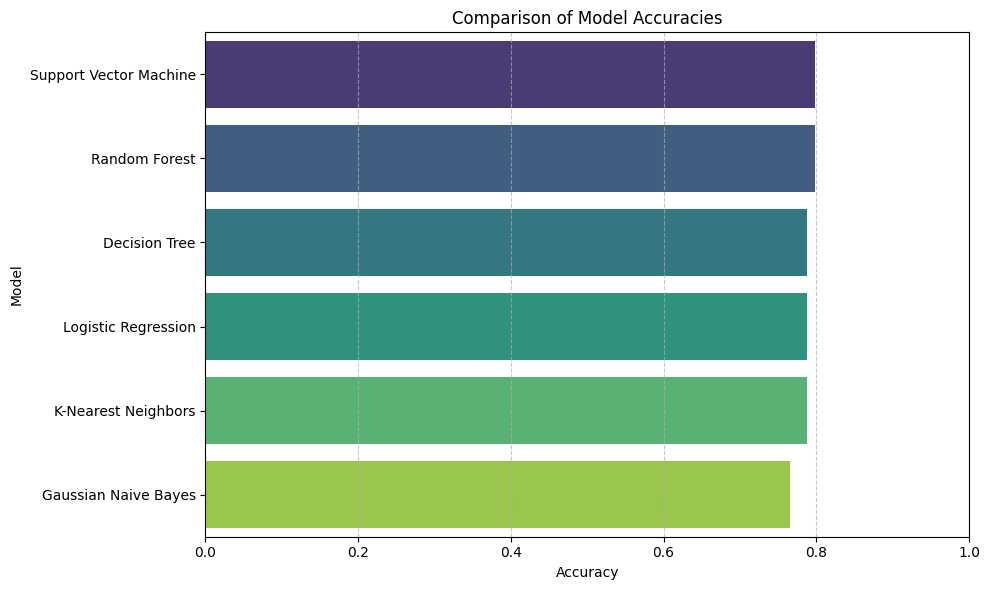

In [112]:
model_accuracies = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Decision Tree': accuracy_score(y_test, dt_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'K-Nearest Neighbors': accuracy_score(y_test, knn_pred),
    'Support Vector Machine': accuracy_score(y_test, svm_pred),
    'Gaussian Naive Bayes': accuracy_score(y_test, nb_pred)
}

accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

print('Model Comparison (Accuracy):')
display(accuracy_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The features are now scaled. You can see the first 5 rows of the scaled features above.